# CLIP vs BLIP: Brain Tumor MRI Classification

This notebook compares two vision-language models — **CLIP** (OpenAI) and **BLIP** (Salesforce) — fine-tuned for brain tumor MRI classification across 4 classes:
- Glioma
- Meningioma
- No Tumor
- Pituitary

Both models use identical training setups (same optimizer, scheduler, epochs, classification head) for a fair comparison. The only difference is the backbone and its preprocessor.

## Cell 1: Imports & Setup

In [5]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from transformers import CLIPModel, BlipModel, BlipProcessor
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Cell 2: Data Pipeline (shared dataset download)

In [6]:
# Download dataset once — reused for both CLIP and BLIP loaders
print("Downloading/Locating dataset...")
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
train_dir = os.path.join(path, 'Training')
test_dir  = os.path.join(path, 'Testing')

CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = 4
BATCH_SIZE  = 16
EPOCHS      = 30

# ── CLIP transforms (normalised to [-1, 1] as used in the original run) ──
clip_train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

clip_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# ── BLIP transforms (BlipProcessor statistics: mean=[0.48, 0.45, 0.40], std=[0.26, 0.26, 0.27]) ──
blip_train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073],
                         std=[0.26862954, 0.26130258, 0.27577711])
])

blip_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073],
                         std=[0.26862954, 0.26130258, 0.27577711])
])

# ── DataLoaders ──
print("Setting up DataLoaders...")

clip_train_dataset = datasets.ImageFolder(root=train_dir, transform=clip_train_transforms)
clip_test_dataset  = datasets.ImageFolder(root=test_dir,  transform=clip_test_transforms)
clip_train_loader  = DataLoader(clip_train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
clip_test_loader   = DataLoader(clip_test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

blip_train_dataset = datasets.ImageFolder(root=train_dir, transform=blip_train_transforms)
blip_test_dataset  = datasets.ImageFolder(root=test_dir,  transform=blip_test_transforms)
blip_train_loader  = DataLoader(blip_train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
blip_test_loader   = DataLoader(blip_test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train samples: {len(clip_train_dataset)} | Test samples: {len(clip_test_dataset)}")
print(f"Classes: {clip_train_dataset.classes}")

Downloading/Locating dataset...
Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Setting up DataLoaders...
Train samples: 5600 | Test samples: 1600
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


## Cell 3: Model Definitions

In [7]:
# ── CLIP Classifier (unchanged from original) ──────────────────────────────
class FineTunedCLIPClassifier(nn.Module):
    def __init__(self, num_classes=4):
        super(FineTunedCLIPClassifier, self).__init__()

        self.clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")

        # Freeze text encoder
        for param in self.clip.text_model.parameters():
            param.requires_grad = False

        # Freeze entire vision encoder, then unfreeze last 2 layers
        for param in self.clip.vision_model.parameters():
            param.requires_grad = False
        for layer in self.clip.vision_model.encoder.layers[-2:]:
            for param in layer.parameters():
                param.requires_grad = True

        # Classification head: 768 -> 512 -> num_classes
        self.classification_head = nn.Sequential(
            nn.Linear(768, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, pixel_values):
        vision_outputs = self.clip.vision_model(pixel_values=pixel_values)
        image_embeds   = vision_outputs.pooler_output
        return self.classification_head(image_embeds)


# ── BLIP Classifier ────────────────────────────────────────────────────────
class FineTunedBLIPClassifier(nn.Module):
    def __init__(self, num_classes=4):
        super(FineTunedBLIPClassifier, self).__init__()

        # Load BLIP from Salesforce
        self.blip = BlipModel.from_pretrained("Salesforce/blip-image-captioning-base")

        # Freeze text encoder
        for param in self.blip.text_model.parameters():
            param.requires_grad = False

        # Freeze entire vision encoder, then unfreeze last 2 layers
        for param in self.blip.vision_model.parameters():
            param.requires_grad = False
        for layer in self.blip.vision_model.encoder.layers[-2:]:
            for param in layer.parameters():
                param.requires_grad = True

        # Identical classification head for fair comparison
        self.classification_head = nn.Sequential(
            nn.Linear(768, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, pixel_values):
        # BLIP's vision model outputs a sequence; take the CLS token (index 0)
        vision_outputs = self.blip.vision_model(pixel_values=pixel_values)
        image_embeds   = vision_outputs.last_hidden_state[:, 0, :]
        return self.classification_head(image_embeds)


print("Model definitions ready.")

Model definitions ready.


## Cell 4: Shared Training Helper

In [8]:
def train_model(model, train_loader, model_name="Model", epochs=30, lr=3e-4):
    """Train a classifier and return per-epoch loss and accuracy history."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=5)

    loss_history = []
    acc_history  = []

    print(f"\n{'='*50}")
    print(f"  Training {model_name}")
    print(f"{'='*50}")

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total   = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(pixel_values=images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted  = torch.max(outputs.data, 1)
            total        += labels.size(0)
            correct      += (predicted == labels).sum().item()

        scheduler.step()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc  = 100 * correct / total
        loss_history.append(epoch_loss)
        acc_history.append(epoch_acc)

        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

    return model, loss_history, acc_history


print("Training helper defined.")

Training helper defined.


## Cell 5: Train CLIP

In [9]:
clip_model = FineTunedCLIPClassifier(num_classes=NUM_CLASSES)

clip_model, clip_loss_history, clip_acc_history = train_model(
    clip_model,
    clip_train_loader,
    model_name="CLIP (openai/clip-vit-base-patch32)",
    epochs=EPOCHS,
    lr=3e-4
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Training CLIP (openai/clip-vit-base-patch32)
Epoch [1/30] | Loss: 0.3725 | Accuracy: 86.00%
Epoch [2/30] | Loss: 0.2327 | Accuracy: 91.34%
Epoch [3/30] | Loss: 0.1690 | Accuracy: 93.88%
Epoch [4/30] | Loss: 0.1142 | Accuracy: 96.12%
Epoch [5/30] | Loss: 0.0899 | Accuracy: 97.09%
Epoch [6/30] | Loss: 0.1756 | Accuracy: 93.43%
Epoch [7/30] | Loss: 0.1499 | Accuracy: 94.62%
Epoch [8/30] | Loss: 0.1174 | Accuracy: 95.62%
Epoch [9/30] | Loss: 0.0774 | Accuracy: 97.38%
Epoch [10/30] | Loss: 0.0525 | Accuracy: 98.21%
Epoch [11/30] | Loss: 0.1414 | Accuracy: 94.88%
Epoch [12/30] | Loss: 0.1043 | Accuracy: 96.29%
Epoch [13/30] | Loss: 0.0766 | Accuracy: 97.54%
Epoch [14/30] | Loss: 0.0660 | Accuracy: 97.64%
Epoch [15/30] | Loss: 0.0448 | Accuracy: 98.64%
Epoch [16/30] | Loss: 0.1073 | Accuracy: 96.21%
Epoch [17/30] | Loss: 0.1063 | Accuracy: 96.18%
Epoch [18/30] | Loss: 0.0705 | Accuracy: 97.61%
Epoch [19/30] | Loss: 0.0559 | Accuracy: 98.02%
Epoch [20/30] | Loss: 0.0392 | Accuracy: 98.54%
E

## Cell 6: Train BLIP

In [10]:
blip_model = FineTunedBLIPClassifier(num_classes=NUM_CLASSES)

blip_model, blip_loss_history, blip_acc_history = train_model(
    blip_model,
    blip_train_loader,
    model_name="BLIP (Salesforce/blip-image-captioning-base)",
    epochs=EPOCHS,
    lr=3e-4
)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

`BlipModel` is going to be deprecated in future release, please use `BlipForConditionalGeneration`, `BlipForQuestionAnswering` or `BlipForImageTextRetrieval` depending on your usecase.


Loading weights:   0%|          | 0/150 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

BlipModel LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                                                             | Status     | 
--------------------------------------------------------------------------------+------------+-
text_decoder.bert.encoder.layer.{0...11}.attention.self.query.weight            | UNEXPECTED | 
text_decoder.bert.encoder.layer.{0...11}.crossattention.self.value.bias         | UNEXPECTED | 
text_decoder.bert.encoder.layer.{0...11}.attention.output.LayerNorm.bias        | UNEXPECTED | 
text_decoder.bert.encoder.layer.{0...11}.output.LayerNorm.weight                | UNEXPECTED | 
text_decoder.bert.encoder.layer.{0...11}.crossattention.self.query.bias         | UNEXPECTED | 
text_decoder.bert.encoder.layer.{0...11}.crossattention.self.value.weight       | UNEXPECTED | 
text_decoder.bert.encoder.layer.{0...11}.attention.output.dense.weight          | UNEXPECTED | 
text_decoder.bert.encoder.layer.{0...11}.crossattention.output.LayerNo


  Training BLIP (Salesforce/blip-image-captioning-base)
Epoch [1/30] | Loss: 0.3886 | Accuracy: 85.14%
Epoch [2/30] | Loss: 0.2363 | Accuracy: 91.41%
Epoch [3/30] | Loss: 0.1724 | Accuracy: 93.79%
Epoch [4/30] | Loss: 0.1152 | Accuracy: 95.91%
Epoch [5/30] | Loss: 0.0767 | Accuracy: 97.30%
Epoch [6/30] | Loss: 0.1738 | Accuracy: 93.50%
Epoch [7/30] | Loss: 0.1483 | Accuracy: 94.39%
Epoch [8/30] | Loss: 0.1003 | Accuracy: 96.36%
Epoch [9/30] | Loss: 0.0668 | Accuracy: 97.82%
Epoch [10/30] | Loss: 0.0508 | Accuracy: 98.25%
Epoch [11/30] | Loss: 0.1249 | Accuracy: 95.55%
Epoch [12/30] | Loss: 0.1012 | Accuracy: 96.48%
Epoch [13/30] | Loss: 0.0784 | Accuracy: 97.36%
Epoch [14/30] | Loss: 0.0502 | Accuracy: 98.39%
Epoch [15/30] | Loss: 0.0361 | Accuracy: 98.82%
Epoch [16/30] | Loss: 0.0782 | Accuracy: 97.11%
Epoch [17/30] | Loss: 0.0864 | Accuracy: 97.14%
Epoch [18/30] | Loss: 0.0573 | Accuracy: 98.05%
Epoch [19/30] | Loss: 0.0362 | Accuracy: 98.70%
Epoch [20/30] | Loss: 0.0253 | Accuracy:

## Cell 7: Training Curve Comparison

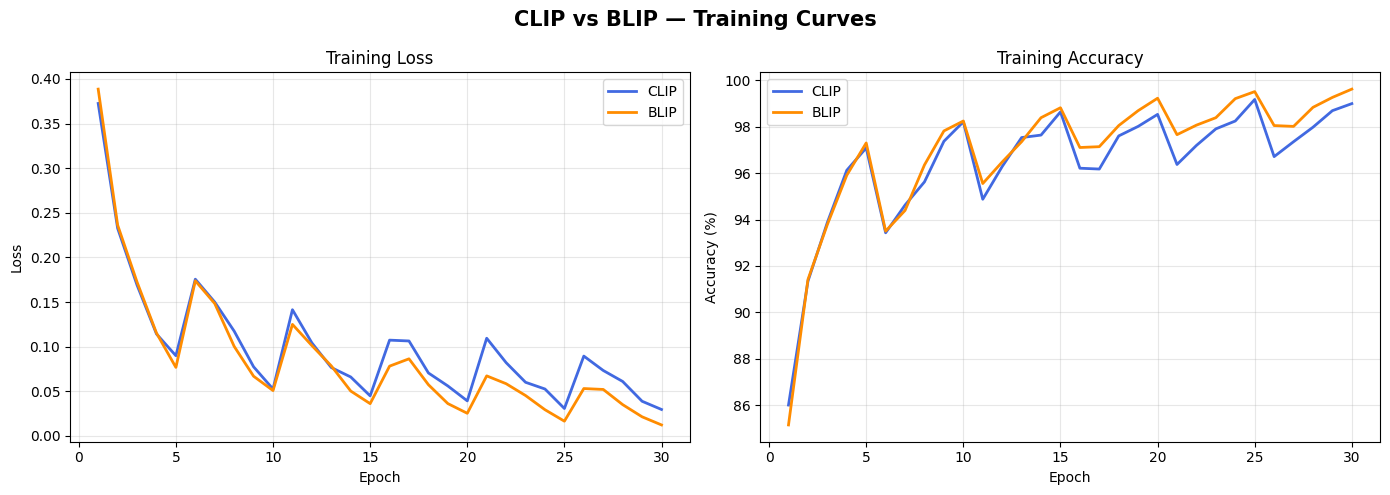

Training curves saved to training_curves.png


In [11]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CLIP vs BLIP — Training Curves', fontsize=15, fontweight='bold')

# Loss
axes[0].plot(epochs_range, clip_loss_history, label='CLIP', color='royalblue',  linewidth=2)
axes[0].plot(epochs_range, blip_loss_history, label='BLIP', color='darkorange', linewidth=2)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, clip_acc_history, label='CLIP', color='royalblue',  linewidth=2)
axes[1].plot(epochs_range, blip_acc_history, label='BLIP', color='darkorange', linewidth=2)
axes[1].set_title('Training Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved to training_curves.png")

## Cell 8: Evaluation on Test Set

In [12]:
def evaluate_model(model, test_loader, model_name="Model"):
    """Evaluate a trained model and return predictions + labels."""
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(pixel_values=images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    accuracy   = 100 * (all_preds == all_labels).sum() / len(all_labels)

    print(f"\n{'='*50}")
    print(f"  {model_name} — Test Results")
    print(f"{'='*50}")
    print(f"Test Accuracy: {accuracy:.2f}%")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

    return all_preds, all_labels, accuracy


clip_preds, clip_labels, clip_test_acc = evaluate_model(clip_model, clip_test_loader, "CLIP")
blip_preds, blip_labels, blip_test_acc = evaluate_model(blip_model, blip_test_loader, "BLIP")


  CLIP — Test Results
Test Accuracy: 93.62%

Classification Report:
              precision    recall  f1-score   support

      glioma       0.95      0.81      0.88       400
  meningioma       0.91      0.95      0.93       400
     notumor       0.90      1.00      0.95       400
   pituitary       0.98      0.98      0.98       400

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.93      1600
weighted avg       0.94      0.94      0.93      1600


  BLIP — Test Results
Test Accuracy: 93.19%

Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      0.77      0.86       400
  meningioma       0.87      0.97      0.92       400
     notumor       0.93      1.00      0.96       400
   pituitary       0.95      0.99      0.97       400

    accuracy                           0.93      1600
   macro avg       0.94      0.93      0.93      1600
weighted avg       0.94      0.93      0.93    

## Cell 9: Confusion Matrices

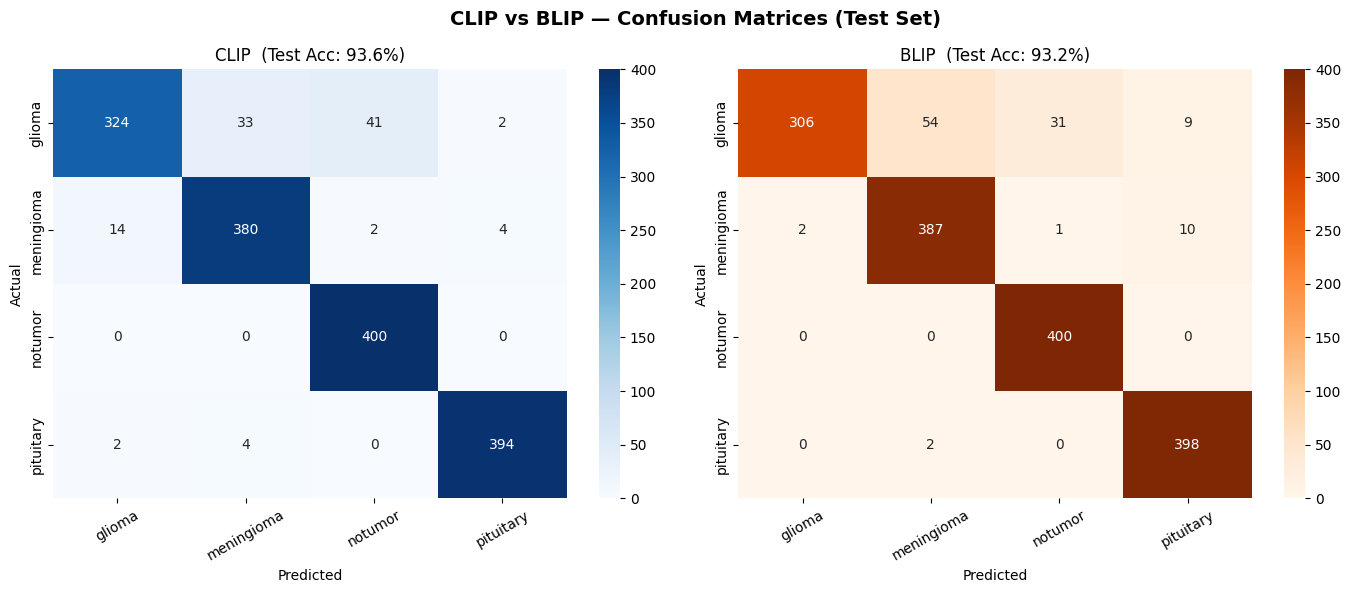

Confusion matrices saved to confusion_matrices.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('CLIP vs BLIP — Confusion Matrices (Test Set)', fontsize=14, fontweight='bold')

for ax, preds, labels, title, color in [
    (axes[0], clip_preds, clip_labels, f'CLIP  (Test Acc: {clip_test_acc:.1f}%)', 'Blues'),
    (axes[1], blip_preds, blip_labels, f'BLIP  (Test Acc: {blip_test_acc:.1f}%)', 'Oranges'),
]:
    cm = confusion_matrix(labels, preds)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=color,
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=ax
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved to confusion_matrices.png")

## Cell 10: Final Summary

In [14]:
print("\n" + "="*55)
print("         CLIP vs BLIP — Final Comparison Summary")
print("="*55)
print(f"  {'Metric':<30} {'CLIP':>10} {'BLIP':>10}")
print("-"*55)
print(f"  {'Final Train Accuracy (%)':<30} {clip_acc_history[-1]:>9.2f}% {blip_acc_history[-1]:>9.2f}%")
print(f"  {'Final Train Loss':<30} {clip_loss_history[-1]:>10.4f} {blip_loss_history[-1]:>10.4f}")
print(f"  {'Test Accuracy (%)':<30} {clip_test_acc:>9.2f}% {blip_test_acc:>9.2f}%")
print("="*55)

winner = "CLIP" if clip_test_acc >= blip_test_acc else "BLIP"
margin = abs(clip_test_acc - blip_test_acc)
print(f"\n  Winner on test set: {winner} (by {margin:.2f}%)")
print("="*55)


         CLIP vs BLIP — Final Comparison Summary
  Metric                               CLIP       BLIP
-------------------------------------------------------
  Final Train Accuracy (%)           99.00%     99.62%
  Final Train Loss                   0.0296     0.0123
  Test Accuracy (%)                  93.62%     93.19%

  Winner on test set: CLIP (by 0.44%)
